# Phase 5: Top-10 Feature Sensitivity Analysis

**Purpose:** Address reviewer feedback by demonstrating that a CatBoost model restricted to the top 10 SHAP-ranked features achieves comparable performance to the full feature model.

**Inputs:**
- `../data/processed/03_cleaned.parquet` — Phase 3 cleaned dataset
- `tuning_results_*/catboost_best_model.pkl` — tuned CatBoost (Model A)
- `tuning_results_*/catboost_study.pkl` — Optuna study with best hyperparameters

**Outputs:**
- `../outputs/model_a_metrics.json` — full-model metrics with bootstrap 95% CIs
- `../outputs/model_b_metrics.json` — top-10 model metrics with bootstrap 95% CIs
- `../outputs/model_b_top10.pkl` — saved top-10 CatBoost model
- `../outputs/figure_1_roc.png`, `figure_2_metrics.png`, `figure_3_shap_perm.png`, `figure_4_shap_ranking.png`, `figure_5_shap_dependence.png`, `figure_7_shap_summary.png`
- `../outputs/khamron_summary.md` — summary text for the response letter

**Methodology:**
1. Reproduce Phase 4's preprocessing pipeline and train/val/test split (same seed)
2. Load saved tuned CatBoost as Model A; verify by re-evaluating on test set
3. Identify top 10 features by manuscript label → engineered column name
4. Train Model B on top-10 subset using Model A's tuned hyperparameters
5. Bootstrap 95% CIs (1000 iterations) for both models on test set
6. SHAP analysis on Model B
7. Generate manuscript-style figures

**Top 10 features (manuscript Figure 4):**
1. Wheezing/Whistling in Chest (Past Year)
2. Close Relative Had Asthma (family history)
3. General Health Condition
4. FEV1/FVC Ratio (engineered from spirometry)
5. Times Received Healthcare (Past Year)
6. Head Cold or Chest Cold (Past 30 Days)
7. Family History × Lung Function (engineered interaction)
8. Forced Expiratory Time (seconds)
9. Crawl/Walk/Run/Play Limitations
10. Airway Obstruction Indicator (engineered binary)

In [62]:
"""
Phase 5 setup: imports, load saved Phase 4 tuned CatBoost and Optuna study.
"""

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
PROCESSED_DIR = Path("../data/processed")
OUTPUTS_DIR = Path("../outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
_dirs = sorted(Path(".").glob("tuning_results_*"), key=lambda p: p.stat().st_mtime)
if not _dirs:
    raise FileNotFoundError("No tuning_results_* directory found. Run 04_model.ipynb first.")
TUNING_DIR = _dirs[-1]
print(f"Using tuning directory: {TUNING_DIR}")

# Verify everything we need exists
required_files = [
    PROCESSED_DIR / "03_cleaned.parquet",
    TUNING_DIR / "catboost_best_model.pkl",
    TUNING_DIR / "catboost_study.pkl",
]
for f in required_files:
    if not f.exists():
        print(f"MISSING: {f}")
    else:
        print(f"  OK: {f} ({f.stat().st_size // 1024} KB)")

# Load the tuned model (Model A) and Optuna study
model_a = joblib.load(TUNING_DIR / "catboost_best_model.pkl")
study_catboost = joblib.load(TUNING_DIR / "catboost_study.pkl")

print()
print(f"Model A type: {type(model_a).__name__}")
print(f"Optuna study has {len(study_catboost.trials)} trials")
print(f"Best trial value (validation sensitivity): {study_catboost.best_value:.3f}")
print()
print("Best CatBoost hyperparameters from Optuna:")
for k, v in study_catboost.best_params.items():
    print(f"  {k}: {v}")

Using tuning directory: tuning_results_20260625_165708
  OK: ..\data\processed\03_cleaned.parquet (518 KB)
  OK: tuning_results_20260625_165708\catboost_best_model.pkl (1263 KB)
  OK: tuning_results_20260625_165708\catboost_study.pkl (58 KB)

Model A type: Pipeline
Optuna study has 100 trials
Best trial value (validation sensitivity): 0.723

Best CatBoost hyperparameters from Optuna:
  iterations: 300
  learning_rate: 0.013600631965985516
  depth: 4
  l2_leaf_reg: 9.797969505949867
  border_count: 183
  bagging_temperature: 0.4029473997967645
  random_strength: 7.398124517651347


In [63]:
"""
Define the transformer classes needed for unpickling Phase 4's saved preprocessed_data.pkl.

These class definitions must exist in the kernel's __main__ before joblib.load() is called,
because the original pickle stored references to NHANESCleaner and ClinicalFeatureEngineer
as classes in __main__.

This cell defines the classes WITHOUT running any preprocessing — that's already done in
the saved pkl. We just need the class definitions accessible.
"""

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

RANDOM_STATE = 42

class NHANESCleaner(BaseEstimator, TransformerMixin):
    """Clean NHANES sentinel codes - learns rules from training data"""
    
    def __init__(self):
        self.continuous_cols_ = None
        self.categorical_cols_ = None
        self.binary_cols_ = None
        
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Known continuous variables (from domain knowledge)
        continuous_whitelist = {
            'BMXBMI', 'BMXHT', 'BMXWT', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BMXHEAD',
            'BMXRECUM', 'BMXSAD1', 'BMXSAD2', 'BMXSAD3', 'BMXSAD4', 'BMXTHICR', 'BMXTRI',
            'BMXSUB', 'BMXCALF', 'SPXNFEV1', 'SPXNFVC', 'SPXNFEV3', 'SPXNFEV6', 'SPXNPEF', 
            'SPXNFET', 'SPXBFEV1', 'SPXBFVC', 'SPXBFEV3', 'SPXBFEV6', 'SPXBPEF',
            'LBXCOT', 'LBXTHC', 'URXUCR', 'URXNAL', 'URXUHG',
            'INDFMPIR', 'RIDAGEYR', 'INDHHIN2', 'DMDEDUC2', 'DMDEDUC3',
            'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXEOPCT', 'LBXBAPCT',
            'LBXIRN', 'LBXSGL', 'LBXGLU', 'LBDGLUSI'
        }
        
        self.continuous_cols_ = []
        self.categorical_cols_ = []
        self.binary_cols_ = []
        
        for col in X_df.columns:
            if col in continuous_whitelist:
                self.continuous_cols_.append(col)
            else:
                s = X_df[col]
                if pd.api.types.is_numeric_dtype(s):
                    vals = s.dropna()
                    if len(vals) > 0:
                        # Check if binary (1/2 coding common in NHANES)
                        unique_vals = set(vals.unique())
                        if unique_vals == {1, 2} or unique_vals == {1.0, 2.0}:
                            self.binary_cols_.append(col)
                        else:
                            near_int = np.all(np.abs(vals - np.round(vals)) < 1e-6)
                            unique_count = len(vals.unique())
                            if near_int and unique_count <= 20:
                                self.categorical_cols_.append(col)
                            else:
                                self.continuous_cols_.append(col)
        
        return self
    
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        big_sentinels = {99, 999, 777, 7777, 9999, 77777, 99999}
        small_sentinels = {7, 9, 77}
        
        # Clean continuous columns (big sentinels only)
        for col in self.continuous_cols_:
            if col in X_df.columns:
                X_df[col] = X_df[col].replace(big_sentinels, np.nan)
        
        # Clean categorical columns (both big and small sentinels)
        for col in self.categorical_cols_:
            if col in X_df.columns:
                X_df[col] = X_df[col].replace(big_sentinels | small_sentinels, np.nan)
        
        # Convert binary variables (1=Yes/Male, 2=No/Female → 1=Yes/Female, 0=No/Male)
        for col in self.binary_cols_:
            if col in X_df.columns:
                X_df[col] = (X_df[col] == 1).astype(float)
                X_df.loc[X[col].isna(), col] = np.nan
        
        return X_df

# ===========================================================================
# COMPREHENSIVE FEATURE ENGINEERING TRANSFORMER
# ===========================================================================


class ClinicalFeatureEngineer(BaseEstimator, TransformerMixin):
    """Create clinical features - all statistics learned from training data"""
    
    def __init__(self):
        self.bmi_mean_ = None
        self.bmi_std_ = None
        self.race_categories_ = None
        self.feature_names_ = None
        
    def fit(self, X, y=None):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Learn BMI statistics from training data only
        if 'BMXBMI' in X_df.columns:
            self.bmi_mean_ = X_df['BMXBMI'].mean()
            self.bmi_std_ = X_df['BMXBMI'].std()
            if self.bmi_std_ == 0 or pd.isna(self.bmi_std_):
                self.bmi_std_ = 1.0
        
        # Learn race categories from training data only
        if 'RIDRETH1' in X_df.columns:
            self.race_categories_ = sorted(X_df['RIDRETH1'].dropna().unique())
        
        return self
    
    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # ==================== SPIROMETRY FEATURES ====================
        if 'SPXNFEV1' in X_df.columns and 'SPXNFVC' in X_df.columns:
            mask = (X_df['SPXNFEV1'].notna() & X_df['SPXNFVC'].notna() & (X_df['SPXNFVC'] > 0))
            
            # Primary ratio
            X_df['fev1_fvc_ratio'] = np.nan
            X_df.loc[mask, 'fev1_fvc_ratio'] = X_df.loc[mask, 'SPXNFEV1'] / X_df.loc[mask, 'SPXNFVC']
            X_df['fev1_fvc_ratio_missing'] = (~mask).astype(int)
            
            # Clinical thresholds
            X_df['obstruction_indicator'] = (X_df['fev1_fvc_ratio'] < 0.8).astype(float)
            X_df['obstruction_mild'] = ((X_df['fev1_fvc_ratio'] >= 0.7) & (X_df['fev1_fvc_ratio'] < 0.8)).astype(float)
            X_df['obstruction_moderate'] = ((X_df['fev1_fvc_ratio'] >= 0.6) & (X_df['fev1_fvc_ratio'] < 0.7)).astype(float)
            X_df['obstruction_severe'] = (X_df['fev1_fvc_ratio'] < 0.6).astype(float)
            
            # FEV1 transformations
            X_df['fev1_log'] = np.log1p(X_df['SPXNFEV1'].fillna(0))
            X_df['fev1_sqrt'] = np.sqrt(X_df['SPXNFEV1'].fillna(0))
            X_df['fev1_squared'] = X_df['SPXNFEV1'].fillna(0) ** 2
            
            # FVC transformations
            X_df['fvc_log'] = np.log1p(X_df['SPXNFVC'].fillna(0))
            X_df['fvc_sqrt'] = np.sqrt(X_df['SPXNFVC'].fillna(0))
            
            # Additional spirometry ratios
            if 'SPXNFEV6' in X_df.columns:
                mask6 = (X_df['SPXNFEV6'] > 0) & (X_df['SPXNFEV1'].notna())
                X_df['fev1_fev6_ratio'] = np.nan
                X_df.loc[mask6, 'fev1_fev6_ratio'] = X_df.loc[mask6, 'SPXNFEV1'] / X_df.loc[mask6, 'SPXNFEV6']
            
            if 'SPXNFEV3' in X_df.columns:
                mask3 = (X_df['SPXNFEV3'] > 0) & (X_df['SPXNFEV1'].notna())
                X_df['fev1_fev3_ratio'] = np.nan
                X_df.loc[mask3, 'fev1_fev3_ratio'] = X_df.loc[mask3, 'SPXNFEV1'] / X_df.loc[mask3, 'SPXNFEV3']
            
            if 'SPXNPEF' in X_df.columns:
                X_df['pef_log'] = np.log1p(X_df['SPXNPEF'].fillna(0))
                pef_mask = (X_df['SPXNPEF'] > 0) & (X_df['SPXNFEV1'] > 0)
                X_df['fev1_pef_ratio'] = np.nan
                X_df.loc[pef_mask, 'fev1_pef_ratio'] = X_df.loc[pef_mask, 'SPXNFEV1'] / X_df.loc[pef_mask, 'SPXNPEF']
            
            # Age-adjusted spirometry
            if 'RIDAGEYR' in X_df.columns:
                age_mask = X_df['RIDAGEYR'] > 0
                X_df['fev1_age_adjusted'] = np.nan
                X_df.loc[age_mask, 'fev1_age_adjusted'] = X_df.loc[age_mask, 'SPXNFEV1'] / X_df.loc[age_mask, 'RIDAGEYR']
                X_df['fvc_age_adjusted'] = np.nan
                X_df.loc[age_mask, 'fvc_age_adjusted'] = X_df.loc[age_mask, 'SPXNFVC'] / X_df.loc[age_mask, 'RIDAGEYR']
                X_df['fev1_age_interaction'] = X_df['SPXNFEV1'].fillna(0) * X_df['RIDAGEYR'].fillna(0)
            
            # Height-adjusted spirometry
            if 'BMXHT' in X_df.columns:
                height_mask = X_df['BMXHT'] > 0
                X_df['fev1_height_adjusted'] = np.nan
                X_df.loc[height_mask, 'fev1_height_adjusted'] = X_df.loc[height_mask, 'SPXNFEV1'] / (X_df.loc[height_mask, 'BMXHT'] / 100)
                X_df['fvc_height_adjusted'] = np.nan
                X_df.loc[height_mask, 'fvc_height_adjusted'] = X_df.loc[height_mask, 'SPXNFVC'] / (X_df.loc[height_mask, 'BMXHT'] / 100)
            
            # Bronchodilator response
            if 'SPXBFEV1' in X_df.columns:
                bd_mask = (X_df['SPXBFEV1'].notna() & X_df['SPXNFEV1'].notna() & (X_df['SPXNFEV1'] > 0))
                X_df['bronchodilator_response'] = np.nan
                X_df.loc[bd_mask, 'bronchodilator_response'] = ((X_df.loc[bd_mask, 'SPXBFEV1'] - X_df.loc[bd_mask, 'SPXNFEV1']) / 
                                                                  X_df.loc[bd_mask, 'SPXNFEV1']) * 100
                X_df['positive_bd_response'] = (X_df['bronchodilator_response'] >= 12).astype(float)
        
        # ==================== COTININE / SMOKE EXPOSURE ====================
        if 'LBXCOT' in X_df.columns:
            X_df['cotinine_log'] = np.log1p(X_df['LBXCOT'].fillna(0))
            X_df['cotinine_sqrt'] = np.sqrt(X_df['LBXCOT'].fillna(0))
            X_df['cotinine_squared'] = X_df['LBXCOT'].fillna(0) ** 2
            X_df['cotinine_missing'] = X_df['LBXCOT'].isna().astype(int)
            
            # Clinical thresholds
            X_df['no_smoke_exposure'] = (X_df['LBXCOT'] <= 0.05).astype(float)
            X_df['smoke_exposure_light'] = ((X_df['LBXCOT'] > 0.05) & (X_df['LBXCOT'] <= 1.0)).astype(float)
            X_df['smoke_exposure_moderate'] = ((X_df['LBXCOT'] > 1.0) & (X_df['LBXCOT'] <= 10.0)).astype(float)
            X_df['smoke_exposure_heavy'] = (X_df['LBXCOT'] > 10.0).astype(float)
            X_df['smoke_exposure_binary'] = (X_df['LBXCOT'] > 1.0).astype(float)
            X_df['likely_active_smoking'] = (X_df['LBXCOT'] > 50).astype(float)
            X_df['likely_passive_smoking'] = ((X_df['LBXCOT'] > 1.0) & (X_df['LBXCOT'] <= 50)).astype(float)
        
        # ==================== ANTHROPOMETRIC FEATURES ====================
        if 'BMXBMI' in X_df.columns:
            X_df['bmi_log'] = np.log1p(X_df['BMXBMI'].fillna(0))
            X_df['bmi_sqrt'] = np.sqrt(X_df['BMXBMI'].fillna(0))
            X_df['bmi_squared'] = X_df['BMXBMI'].fillna(0) ** 2
            X_df['bmi_missing'] = X_df['BMXBMI'].isna().astype(int)
            
            # BMI categories
            X_df['underweight'] = (X_df['BMXBMI'] < 18.5).astype(float)
            X_df['normal_weight'] = ((X_df['BMXBMI'] >= 18.5) & (X_df['BMXBMI'] < 25)).astype(float)
            X_df['overweight'] = ((X_df['BMXBMI'] >= 25) & (X_df['BMXBMI'] < 30)).astype(float)
            X_df['obese'] = (X_df['BMXBMI'] >= 30).astype(float)
            X_df['severely_obese'] = (X_df['BMXBMI'] >= 35).astype(float)
            
            # BMI Z-score using TRAINING statistics
            if self.bmi_mean_ is not None and self.bmi_std_ is not None:
                X_df['bmi_zscore'] = (X_df['BMXBMI'] - self.bmi_mean_) / self.bmi_std_
            
            # Age-adjusted BMI
            if 'RIDAGEYR' in X_df.columns:
                age_bmi_mask = (X_df['BMXBMI'].notna() & X_df['RIDAGEYR'].notna() & (X_df['RIDAGEYR'] > 0))
                X_df['bmi_age_adjusted'] = np.nan
                X_df.loc[age_bmi_mask, 'bmi_age_adjusted'] = X_df.loc[age_bmi_mask, 'BMXBMI'] / X_df.loc[age_bmi_mask, 'RIDAGEYR']
                X_df['bmi_age_interaction'] = X_df['BMXBMI'].fillna(0) * X_df['RIDAGEYR'].fillna(0)
        
        # Height features
        if 'BMXHT' in X_df.columns:
            X_df['height_log'] = np.log1p(X_df['BMXHT'].fillna(0))
            X_df['height_squared'] = X_df['BMXHT'].fillna(0) ** 2
            
            if 'RIDAGEYR' in X_df.columns:
                age_ht_mask = (X_df['BMXHT'].notna() & X_df['RIDAGEYR'].notna() & (X_df['RIDAGEYR'] > 0))
                X_df['height_age_ratio'] = np.nan
                X_df.loc[age_ht_mask, 'height_age_ratio'] = X_df.loc[age_ht_mask, 'BMXHT'] / X_df.loc[age_ht_mask, 'RIDAGEYR']
        
        # Weight features
        if 'BMXWT' in X_df.columns:
            X_df['weight_log'] = np.log1p(X_df['BMXWT'].fillna(0))
            X_df['weight_sqrt'] = np.sqrt(X_df['BMXWT'].fillna(0))
            
            if 'RIDAGEYR' in X_df.columns:
                age_wt_mask = (X_df['BMXWT'].notna() & X_df['RIDAGEYR'].notna() & (X_df['RIDAGEYR'] > 0))
                X_df['weight_age_ratio'] = np.nan
                X_df.loc[age_wt_mask, 'weight_age_ratio'] = X_df.loc[age_wt_mask, 'BMXWT'] / X_df.loc[age_wt_mask, 'RIDAGEYR']
        
        # Waist features
        if 'BMXWAIST' in X_df.columns:
            X_df['waist_log'] = np.log1p(X_df['BMXWAIST'].fillna(0))
            
            if 'BMXHT' in X_df.columns:
                waist_ht_mask = (X_df['BMXWAIST'] > 0) & (X_df['BMXHT'] > 0)
                X_df['waist_height_ratio'] = np.nan
                X_df.loc[waist_ht_mask, 'waist_height_ratio'] = X_df.loc[waist_ht_mask, 'BMXWAIST'] / X_df.loc[waist_ht_mask, 'BMXHT']
                X_df['waist_height_risk'] = (X_df['waist_height_ratio'] > 0.5).astype(float)
        
        # ==================== FAMILY HISTORY INTERACTIONS ====================
        if 'MCQ300B' in X_df.columns:
            X_df['MCQ300B_missing'] = X_df['MCQ300B'].isna().astype(int)
            
            if 'fev1_fvc_ratio' in X_df.columns:
                X_df['family_spirometry_interaction'] = X_df['MCQ300B'].fillna(0) * X_df['fev1_fvc_ratio'].fillna(0)
                X_df['family_obstruction_interaction'] = X_df['MCQ300B'].fillna(0) * X_df['obstruction_indicator'].fillna(0)
            
            if 'smoke_exposure_heavy' in X_df.columns:
                X_df['family_smoke_interaction'] = X_df['MCQ300B'].fillna(0) * X_df['smoke_exposure_heavy'].fillna(0)
            if 'cotinine_log' in X_df.columns:
                X_df['family_cotinine_interaction'] = X_df['MCQ300B'].fillna(0) * X_df['cotinine_log'].fillna(0)
            
            if 'obese' in X_df.columns:
                X_df['family_obesity_interaction'] = X_df['MCQ300B'].fillna(0) * X_df['obese'].fillna(0)
            if 'BMXBMI' in X_df.columns:
                X_df['family_bmi_interaction'] = X_df['MCQ300B'].fillna(0) * X_df['BMXBMI'].fillna(0)
            
            if 'RIDAGEYR' in X_df.columns:
                X_df['family_age_interaction'] = X_df['MCQ300B'].fillna(0) * X_df['RIDAGEYR'].fillna(0)
        
        # ==================== AGE FEATURES ====================
        if 'RIDAGEYR' in X_df.columns:
            X_df['age_squared'] = X_df['RIDAGEYR'] ** 2
            X_df['age_cubed'] = X_df['RIDAGEYR'] ** 3
            X_df['age_log'] = np.log1p(X_df['RIDAGEYR'])
            X_df['age_sqrt'] = np.sqrt(X_df['RIDAGEYR'])
            
            # Age groups
            X_df['age_group_6_8'] = ((X_df['RIDAGEYR'] >= 6) & (X_df['RIDAGEYR'] < 9)).astype(float)
            X_df['age_group_9_12'] = ((X_df['RIDAGEYR'] >= 9) & (X_df['RIDAGEYR'] < 13)).astype(float)
            X_df['age_group_13_15'] = ((X_df['RIDAGEYR'] >= 13) & (X_df['RIDAGEYR'] < 16)).astype(float)
            X_df['age_group_16_17'] = ((X_df['RIDAGEYR'] >= 16) & (X_df['RIDAGEYR'] < 18)).astype(float)
            
            # Developmental stages
            X_df['pre_pubertal'] = (X_df['RIDAGEYR'] < 11).astype(float)
            X_df['likely_pubertal'] = ((X_df['RIDAGEYR'] >= 11) & (X_df['RIDAGEYR'] <= 15)).astype(float)
            X_df['post_pubertal'] = (X_df['RIDAGEYR'] > 15).astype(float)
            
            X_df['early_adolescent'] = ((X_df['RIDAGEYR'] >= 10) & (X_df['RIDAGEYR'] < 13)).astype(float)
            X_df['mid_adolescent'] = ((X_df['RIDAGEYR'] >= 13) & (X_df['RIDAGEYR'] < 16)).astype(float)
            X_df['late_adolescent'] = (X_df['RIDAGEYR'] >= 16).astype(float)
        
        # ==================== GENDER INTERACTIONS ====================
        if 'RIAGENDR' in X_df.columns:
            if 'RIDAGEYR' in X_df.columns:
                X_df['gender_age_interaction'] = X_df['RIAGENDR'].fillna(0) * X_df['RIDAGEYR'].fillna(0)
                X_df['female_adolescent'] = (X_df['RIAGENDR'].fillna(0) * X_df['likely_pubertal'].fillna(0))
            
            if 'obese' in X_df.columns:
                X_df['gender_obesity_interaction'] = X_df['RIAGENDR'].fillna(0) * X_df['obese'].fillna(0)
            
            if 'smoke_exposure_heavy' in X_df.columns:
                X_df['gender_smoke_interaction'] = X_df['RIAGENDR'].fillna(0) * X_df['smoke_exposure_heavy'].fillna(0)
            
            if 'fev1_fvc_ratio' in X_df.columns:
                X_df['gender_spirometry_interaction'] = X_df['RIAGENDR'].fillna(0) * X_df['fev1_fvc_ratio'].fillna(0)
        
        # ==================== RACE/ETHNICITY FEATURES ====================
        if 'RIDRETH1' in X_df.columns and self.race_categories_ is not None:
            # Use only categories seen during training
            for race_val in self.race_categories_:
                X_df[f'race_{int(race_val)}'] = (X_df['RIDRETH1'] == race_val).astype(float)
            
            if 'smoke_exposure_heavy' in X_df.columns:
                X_df['race_smoke_interaction'] = X_df['RIDRETH1'].fillna(0) * X_df['smoke_exposure_heavy'].fillna(0)
        
        # ==================== SOCIOECONOMIC FEATURES ====================
        if 'INDFMPIR' in X_df.columns:
            X_df['poverty_income_ratio_log'] = np.log1p(X_df['INDFMPIR'].fillna(0))
            X_df['poverty_income_ratio_sqrt'] = np.sqrt(X_df['INDFMPIR'].fillna(0))
            X_df['poverty_income_ratio_missing'] = X_df['INDFMPIR'].isna().astype(int)
            
            # Poverty thresholds
            X_df['extreme_poverty'] = (X_df['INDFMPIR'] < 0.5).astype(float)
            X_df['poverty'] = ((X_df['INDFMPIR'] >= 0.5) & (X_df['INDFMPIR'] < 1.0)).astype(float)
            X_df['low_income'] = ((X_df['INDFMPIR'] >= 1.0) & (X_df['INDFMPIR'] < 2.0)).astype(float)
            X_df['middle_income'] = ((X_df['INDFMPIR'] >= 2.0) & (X_df['INDFMPIR'] < 4.0)).astype(float)
            X_df['high_income'] = (X_df['INDFMPIR'] >= 4.0).astype(float)
            
            if 'smoke_exposure_heavy' in X_df.columns:
                X_df['poverty_smoke_interaction'] = X_df['low_income'].fillna(0) * X_df['smoke_exposure_heavy'].fillna(0)
        
        # ==================== RESPIRATORY SYMPTOMS ====================
        if 'RDQ070' in X_df.columns:
            X_df['RDQ070_missing'] = X_df['RDQ070'].isna().astype(int)
            
            if 'fev1_fvc_ratio' in X_df.columns:
                X_df['wheeze_spirometry_interaction'] = X_df['RDQ070'].fillna(0) * X_df['fev1_fvc_ratio'].fillna(0)
            
            if 'smoke_exposure_heavy' in X_df.columns:
                X_df['wheeze_smoke_interaction'] = X_df['RDQ070'].fillna(0) * X_df['smoke_exposure_heavy'].fillna(0)
        
        # Other medical conditions
        for mcq_var in ['MCQ092', 'MCQ053', 'MCQ140']:
            if mcq_var in X_df.columns:
                X_df[f'{mcq_var}_missing'] = X_df[mcq_var].isna().astype(int)
        
        # Sleep features
        for sleep_var in ['SPQ010', 'SPQ040', 'SPQ050']:
            if sleep_var in X_df.columns:
                X_df[f'{sleep_var}_missing'] = X_df[sleep_var].isna().astype(int)
        
        # ==================== LABORATORY VALUES ====================
        if 'LBXWBCSI' in X_df.columns:
            X_df['wbc_log'] = np.log1p(X_df['LBXWBCSI'].fillna(0))
            X_df['wbc_elevated'] = (X_df['LBXWBCSI'] > 11.0).astype(float)
        
        if 'LBXEOPCT' in X_df.columns:
            X_df['eosinophil_elevated'] = (X_df['LBXEOPCT'] > 4.0).astype(float)
            X_df['eosinophil_log'] = np.log1p(X_df['LBXEOPCT'].fillna(0))
        
        # ==================== MISSING VALUE PATTERNS ====================
        # Only count missingness for NON-LEAKY variables
        important_vars = ['RDQ070', 'MCQ092', 'MCQ140', 'MCQ053', 'SPQ010', 'SPQ040',
                         'SPXNFEV1', 'SPXNFVC', 'LBXCOT', 'BMXBMI']
        
        for var in important_vars:
            if var in X_df.columns and f'{var}_missing' not in X_df.columns:
                X_df[f'{var}_missing'] = X_df[var].isna().astype(int)
        
        X_df['total_missing'] = X_df.isna().sum(axis=1)
        X_df['missing_proportion'] = X_df['total_missing'] / len(X_df.columns)
        X_df['has_spirometry'] = ((X_df['SPXNFEV1'].notna()) | (X_df['SPXNFVC'].notna())).astype(int)
        X_df['has_cotinine'] = X_df['LBXCOT'].notna().astype(int)
        X_df['has_bmi'] = X_df['BMXBMI'].notna().astype(int)
        X_df['complete_core_data'] = ((X_df['has_spirometry'] == 1) & 
                                       (X_df['has_cotinine'] == 1) & 
                                       (X_df['has_bmi'] == 1)).astype(int)
        
        # ==================== POLYNOMIAL INTERACTIONS ====================
        if 'RIDAGEYR' in X_df.columns and 'BMXBMI' in X_df.columns:
            X_df['age_bmi_poly'] = X_df['RIDAGEYR'].fillna(0) * X_df['BMXBMI'].fillna(0) ** 2
        
        if 'fev1_fvc_ratio' in X_df.columns and 'RIDAGEYR' in X_df.columns:
            X_df['spirometry_age_poly'] = X_df['fev1_fvc_ratio'].fillna(0) * X_df['RIDAGEYR'].fillna(0) ** 2
        
        self.feature_names_ = X_df.columns.tolist()
        
        return X_df
    
    def get_feature_names_out(self, input_features=None):
        return self.feature_names_ if self.feature_names_ is not None else []

# ===========================================================================
# FEATURE SELECTION
# ===========================================================================



print("✓ NHANESCleaner and ClinicalFeatureEngineer classes defined in kernel.")
print("  joblib.load() can now successfully unpickle preprocessed_data.pkl.")


✓ NHANESCleaner and ClinicalFeatureEngineer classes defined in kernel.
  joblib.load() can now successfully unpickle preprocessed_data.pkl.


In [64]:
"""
Load Phase 4's saved preprocessed data — the exact data state Model A was trained on.

This includes:
- All four fitted preprocessing transformers (cleaner, feat_eng, imputer, scaler)
- The exact train/val/test splits
- Sample weights for each split
- The list of feature names after engineering
"""

preprocessed = joblib.load(TUNING_DIR / "preprocessed_data.pkl")

# Unpack what we need
cleaner = preprocessed['cleaner']
feat_eng = preprocessed['feat_eng']
imputer = preprocessed['imputer']
scaler = preprocessed['scaler']

X_train = preprocessed['X_train']
y_train = preprocessed['y_train']
X_val = preprocessed['X_val']
y_val = preprocessed['y_val']
X_test = preprocessed['X_test']
y_test = preprocessed['y_test']

sw_train = preprocessed['sw_train']
sw_val = preprocessed['sw_val']
sw_test = preprocessed['sw_test']

feature_names = preprocessed['feature_names']

# Confirm we got everything aligned
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print()
print(f"y_train asthma prevalence: {np.mean(y_train):.1%}")
print(f"y_test asthma prevalence:  {np.mean(y_test):.1%}")
print()
print(f"Number of feature names: {len(feature_names)}")
print(f"First 10 feature names: {feature_names[:10]}")
print()
print(f"Last 5 feature names: {feature_names[-5:]}")

X_train: (3939, 103)
X_val:   (1314, 103)
X_test:  (1314, 103)

y_train asthma prevalence: 18.7%
y_test asthma prevalence:  18.7%

Number of feature names: 103
First 10 feature names: ['RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'DMDCITZN', 'DMDEDUC3', 'DMDHHSIZ', 'DMDFMSIZ', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR']

Last 5 feature names: ['family_spirometry_interaction', 'SPXNFEV1_missing', 'SPXNFVC_missing', 'LBXCOT_missing', 'BMXBMI_missing']


In [65]:
"""
Map the manuscript's top 10 feature labels to actual column names in `feature_names`.

The manuscript reports labels like "Wheezing/Whistling in Chest (Past Year)" but our
feature matrix uses NHANES variable codes (RDQ070) and engineered feature names
(fev1_fvc_ratio, airway_obstruction, etc.).

This cell prints all 112 feature names so we can find the top 10 by inspection.
"""

# Print all feature names with their indices for reference
print("All 112 feature names:")
print("=" * 60)
for i, name in enumerate(feature_names):
    print(f"  {i:3d}: {name}")

All 112 feature names:
    0: RIAGENDR
    1: RIDAGEYR
    2: RIDRETH1
    3: DMDCITZN
    4: DMDEDUC3
    5: DMDHHSIZ
    6: DMDFMSIZ
    7: INDHHIN2
    8: INDFMIN2
    9: INDFMPIR
   10: DMDHRGND
   11: DMDHRAGE
   12: DMDHREDU
   13: DMDHRMAR
   14: DMDHSEDU
   15: FIALANG
   16: BMXWT
   17: BMXHT
   18: BMXBMI
   19: BMXLEG
   20: BMXARML
   21: BMXARMC
   22: BMXWAIST
   23: MCQ053
   24: MCQ092
   25: MCQ140
   26: MCQ300B
   27: ENQ010
   28: ENQ020
   29: SPQ010
   30: SPQ020
   31: SPQ040
   32: SPQ060
   33: SPQ100
   34: ENQ100
   35: SPXNSTAT
   36: SPXNFVC
   37: SPXNEV
   38: SPXNFEV5
   39: SPXNFEV7
   40: SPXNFEV1
   41: SPXNFEV3
   42: SPXNFEV6
   43: SPXNPEF
   44: SPXNF257
   45: SPXNFET
   46: SPDNACC
   47: SPDBRONC
   48: LBXCOT
   49: LBDCOTLC
   50: URXNAL
   51: URDNALLC
   52: URXUCR
   53: FSD032A
   54: FSD032B
   55: FSD032C
   56: FSD032D
   57: FSD032E
   58: FSD032F
   59: FSDHH
   60: FSDAD
   61: FSDCH
   62: FSD151
   63: FSQ165
   64: FSQ162
   65:

In [66]:
"""
Train Model B: CatBoost restricted to the top 10 SHAP-ranked features from the
manuscript, using the same tuned hyperparameters as Model A.

This is the sensitivity analysis — the question being: does removing all features
beyond the top 10 substantially change model performance?
"""

from catboost import CatBoostClassifier

# Top 10 features mapped from manuscript Figure 4 to actual column names
TOP_10_FEATURES = [
    'RDQ070',                            # 1. Wheezing/Whistling in Chest (Past Year)
    'MCQ300B',                           # 2. Close Relative Had Asthma
    'HUQ010',                            # 3. General Health Condition
    'fev1_fvc_ratio',                    # 4. FEV1/FVC Ratio
    'HUQ050',                            # 5. Times Received Healthcare (Past Year)
    'HSQ500',                            # 6. Head Cold or Chest Cold (Past 30 Days)
    'family_spirometry_interaction',     # 7. Family History × Lung Function
    'SPXNFET',                           # 8. Forced Expiratory Time (seconds)
    'PFQ020',                            # 9. Crawl/Walk/Run/Play Limitations
    'obstruction_indicator',             # 10. Airway Obstruction Indicator
]

# Verify all 10 are in feature_names
missing = [f for f in TOP_10_FEATURES if f not in feature_names]
if missing:
    print(f"❌ MISSING: {missing}")
    raise ValueError(f"Top-10 features missing from preprocessed data: {missing}")
else:
    print(f"✓ All 10 features confirmed in feature_names list")

# Get column indices for slicing the numpy arrays
top_10_indices = [feature_names.index(f) for f in TOP_10_FEATURES]
print(f"  Indices: {top_10_indices}")

# Slice train/val/test to top-10 features only
X_train_top10 = X_train[:, top_10_indices]
X_val_top10 = X_val[:, top_10_indices]
X_test_top10 = X_test[:, top_10_indices]

print()
print(f"X_train_top10: {X_train_top10.shape}")
print(f"X_val_top10:   {X_val_top10.shape}")
print(f"X_test_top10:  {X_test_top10.shape}")

# Phase 4's tuned hyperparameters (loaded from study_catboost.best_params)
best_params = study_catboost.best_params
print()
print(f"Using Phase 4's tuned hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Configure CatBoost with the same tuned settings
catboost_params = {
    **best_params,
    'random_state': RANDOM_STATE,
    'verbose': False,
    'thread_count': -1,
}

# Train Model B
print()
print("Training Model B (CatBoost on top 10 features)...")
import time
start = time.time()
model_b = CatBoostClassifier(**catboost_params)
model_b.fit(X_train_top10, y_train, sample_weight=sw_train)
elapsed = time.time() - start
print(f"✓ Trained in {elapsed:.1f}s")

# Save the model
joblib.dump(model_b, OUTPUTS_DIR / "model_b_top10.pkl")
print(f"✓ Saved to: {OUTPUTS_DIR / 'model_b_top10.pkl'}")

✓ All 10 features confirmed in feature_names list
  Indices: [80, 26, 71, 87, 75, 68, 98, 45, 78, 88]

X_train_top10: (3939, 10)
X_val_top10:   (1314, 10)
X_test_top10:  (1314, 10)

Using Phase 4's tuned hyperparameters:
  iterations: 300
  learning_rate: 0.013600631965985516
  depth: 4
  l2_leaf_reg: 9.797969505949867
  border_count: 183
  bagging_temperature: 0.4029473997967645
  random_strength: 7.398124517651347

Training Model B (CatBoost on top 10 features)...


✓ Trained in 0.4s
✓ Saved to: ..\outputs\model_b_top10.pkl


In [67]:
print(f"Model B exists: {model_b is not None}")
print(f"Model B has {model_b.tree_count_} trees")
print(f"X_train_top10 still in memory: shape {X_train_top10.shape}")

Model B exists: True
Model B has 300 trees
X_train_top10 still in memory: shape (3939, 10)


In [68]:
"""
Cell 6: Evaluate Model A (full features) and Model B (top 10) on the held-out test set.
Compute AUC, sensitivity, specificity, PPV, NPV, F1, MCC, Brier with bootstrap 95% CIs.

Both models share the same X_test/y_test, so this is a direct comparison.
Model A uses the full 112-feature X_test; Model B uses X_test_top10 (10 features).

This version (v2) converts pandas Series to numpy arrays before bootstrap to ensure
positional indexing works correctly with current pandas. Also uses per-metric
resilience so a single failure doesn't drop the whole resample.
"""

from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score,
    matthews_corrcoef, brier_score_loss
)
import time

N_BOOTSTRAP = 1000  # iterations for 95% CIs
THRESHOLD = 0.5     # decision threshold for binary predictions

# Get prediction probabilities for both models on test set
print("Generating predictions...")
y_proba_a = model_a.predict_proba(X_test)[:, 1]
y_proba_b = model_b.predict_proba(X_test_top10)[:, 1]

# Apply threshold to get binary predictions
y_pred_a = (y_proba_a >= THRESHOLD).astype(int)
y_pred_b = (y_proba_b >= THRESHOLD).astype(int)

print(f"  Model A predictions on {len(y_test):,} test samples")
print(f"  Model B predictions on {len(y_test):,} test samples")
print()


def compute_metrics(y_true, y_pred, y_proba):
    """Returns dict of all metrics for one model."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    return {
        'AUC':         roc_auc_score(y_true, y_proba),
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'PPV':         ppv,
        'NPV':         npv,
        'F1':          f1_score(y_true, y_pred),
        'MCC':         matthews_corrcoef(y_true, y_pred),
        'Brier':       brier_score_loss(y_true, y_proba),
    }


def bootstrap_ci(y_true, y_pred, y_proba, n_iterations=1000, seed=42):
    """Compute 95% CIs for all metrics via bootstrap resampling.

    Inputs must be numpy arrays (not pandas Series) for positional indexing.
    Each metric is computed independently so a failure in one doesn't drop the
    whole resample. Resamples with only one class are skipped (AUC undefined).
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    metric_keys = ['AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1', 'MCC', 'Brier']
    samples = {k: [] for k in metric_keys}

    for i in range(n_iterations):
        idx = rng.choice(n, size=n, replace=True)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_proba[idx]

        # Skip resamples with only one class — AUC undefined
        if len(np.unique(yt)) < 2:
            continue

        # Compute each metric independently
        try: samples['AUC'].append(roc_auc_score(yt, ypr))
        except Exception: pass

        try:
            tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
            samples['Sensitivity'].append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            samples['Specificity'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
            samples['PPV'].append(tp / (tp + fp) if (tp + fp) > 0 else 0)
            samples['NPV'].append(tn / (tn + fn) if (tn + fn) > 0 else 0)
        except Exception: pass

        try: samples['F1'].append(f1_score(yt, yp))
        except Exception: pass

        try: samples['MCC'].append(matthews_corrcoef(yt, yp))
        except Exception: pass

        try: samples['Brier'].append(brier_score_loss(yt, ypr))
        except Exception: pass

    cis = {}
    for k in metric_keys:
        arr = np.array(samples[k])
        if len(arr) == 0:
            cis[k] = (float('nan'), float('nan'))
            print(f"  ⚠️  {k}: 0 valid resamples, returning NaN CI")
        else:
            cis[k] = (float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5)))
    return cis


# Compute point metrics
metrics_a = compute_metrics(y_test, y_pred_a, y_proba_a)
metrics_b = compute_metrics(y_test, y_pred_b, y_proba_b)

# Convert to numpy arrays for positional bootstrap indexing
# (avoids pandas-3 label-based indexing issues)
y_test_arr = np.asarray(y_test)
y_pred_a_arr = np.asarray(y_pred_a)
y_pred_b_arr = np.asarray(y_pred_b)
y_proba_a_arr = np.asarray(y_proba_a)
y_proba_b_arr = np.asarray(y_proba_b)

# Bootstrap CIs (this is the slow part)
print(f"Bootstrapping {N_BOOTSTRAP} resamples per model...")
start = time.time()
cis_a = bootstrap_ci(y_test_arr, y_pred_a_arr, y_proba_a_arr, n_iterations=N_BOOTSTRAP)
print(f"  Model A done ({time.time()-start:.1f}s)")
start = time.time()
cis_b = bootstrap_ci(y_test_arr, y_pred_b_arr, y_proba_b_arr, n_iterations=N_BOOTSTRAP)
print(f"  Model B done ({time.time()-start:.1f}s)")

# Print comparison table
print()
print("=" * 78)
print(f"{'Metric':<14} {'Model A (full, 112 features)':<32} {'Model B (top 10 features)':<32}")
print("-" * 78)
for metric in ['AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1', 'MCC', 'Brier']:
    a_val = metrics_a[metric]
    a_lo, a_hi = cis_a[metric]
    b_val = metrics_b[metric]
    b_lo, b_hi = cis_b[metric]
    print(f"{metric:<14} {a_val:.3f} ({a_lo:.3f}, {a_hi:.3f})         {b_val:.3f} ({b_lo:.3f}, {b_hi:.3f})")
print("=" * 78)

# Save metrics to JSON for downstream use
results = {
    'model_a_full_features': {
        'point_estimates': metrics_a,
        'confidence_intervals_95': {k: list(v) for k, v in cis_a.items()},
        'n_features': 103,
        'n_test_samples': int(len(y_test)),
    },
    'model_b_top10_features': {
        'point_estimates': metrics_b,
        'confidence_intervals_95': {k: list(v) for k, v in cis_b.items()},
        'n_features': 10,
        'feature_list': TOP_10_FEATURES,
        'n_test_samples': int(len(y_test)),
    },
    'comparison_setup': {
        'same_train_test_split': True,
        'same_random_seed': RANDOM_STATE,
        'same_hyperparameters': True,
        'hyperparameters': dict(best_params),
        'bootstrap_iterations': N_BOOTSTRAP,
    },
}
with open(OUTPUTS_DIR / "model_comparison_metrics.json", 'w') as f:
    json.dump(results, f, indent=2)
print()
print(f"✓ Saved: {OUTPUTS_DIR / 'model_comparison_metrics.json'}")


Generating predictions...
  Model A predictions on 1,314 test samples
  Model B predictions on 1,314 test samples

Bootstrapping 1000 resamples per model...


  Model A done (3.0s)
  Model B done (2.9s)

Metric         Model A (full, 112 features)     Model B (top 10 features)       
------------------------------------------------------------------------------
AUC            0.827 (0.795, 0.856)         0.803 (0.771, 0.833)
Sensitivity    0.760 (0.703, 0.812)         0.163 (0.118, 0.208)
Specificity    0.747 (0.722, 0.771)         0.989 (0.982, 0.995)
PPV            0.409 (0.368, 0.456)         0.769 (0.648, 0.887)
NPV            0.931 (0.913, 0.948)         0.837 (0.817, 0.857)
F1             0.532 (0.488, 0.576)         0.268 (0.202, 0.333)
MCC            0.416 (0.365, 0.468)         0.303 (0.236, 0.367)
Brier          0.185 (0.174, 0.196)         0.119 (0.108, 0.130)

✓ Saved: ..\outputs\model_comparison_metrics.json


In [69]:
"""
Threshold tuning: find the decision threshold that achieves sensitivity >= 80%
with the highest possible specificity, using the validation set. Then evaluate
both models at their tuned thresholds on the test set.

This matches the methodology of the original published analysis, which constrained
CatBoost to sensitivity >= 80% (the screening operating point).

Both models tuned the same way ensures fair head-to-head comparison.
"""

from sklearn.metrics import roc_curve

TARGET_SENSITIVITY = 0.80


def find_threshold_for_sensitivity(y_true, y_proba, target_sens=0.80):
    """Find the highest threshold whose sensitivity >= target_sens on the given set.
    Returns (threshold, achieved_sensitivity, achieved_specificity)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    # tpr = sensitivity. Find thresholds where tpr >= target.
    valid = tpr >= target_sens
    if not valid.any():
        # Can't achieve target — return the highest-sensitivity threshold available
        best_idx = np.argmax(tpr)
    else:
        # Among thresholds that meet the constraint, pick the one with highest threshold
        # (= lowest fpr = highest specificity)
        valid_indices = np.where(valid)[0]
        best_idx = valid_indices[np.argmax(thresholds[valid_indices])]
    return thresholds[best_idx], tpr[best_idx], 1 - fpr[best_idx]


# Tune Model A on validation
y_proba_a_val = model_a.predict_proba(X_val)[:, 1]
threshold_a, sens_a_val, spec_a_val = find_threshold_for_sensitivity(
    np.asarray(y_val), y_proba_a_val, target_sens=TARGET_SENSITIVITY
)

# Tune Model B on validation
y_proba_b_val = model_b.predict_proba(X_val_top10)[:, 1]
threshold_b, sens_b_val, spec_b_val = find_threshold_for_sensitivity(
    np.asarray(y_val), y_proba_b_val, target_sens=TARGET_SENSITIVITY
)

print("Threshold tuning on VALIDATION set:")
print(f"  Model A: threshold={threshold_a:.4f}  → sens={sens_a_val:.3f}, spec={spec_a_val:.3f}")
print(f"  Model B: threshold={threshold_b:.4f}  → sens={sens_b_val:.3f}, spec={spec_b_val:.3f}")
print()

# Apply tuned thresholds to TEST set predictions
y_pred_a_tuned = (y_proba_a >= threshold_a).astype(int)
y_pred_b_tuned = (y_proba_b >= threshold_b).astype(int)

# Compute new point metrics
metrics_a_tuned = compute_metrics(y_test, y_pred_a_tuned, y_proba_a)
metrics_b_tuned = compute_metrics(y_test, y_pred_b_tuned, y_proba_b)

# Bootstrap CIs at tuned thresholds
y_pred_a_tuned_arr = np.asarray(y_pred_a_tuned)
y_pred_b_tuned_arr = np.asarray(y_pred_b_tuned)

print("Bootstrapping at tuned thresholds...")
start = time.time()
cis_a_tuned = bootstrap_ci(y_test_arr, y_pred_a_tuned_arr, y_proba_a_arr, n_iterations=N_BOOTSTRAP)
print(f"  Model A done ({time.time()-start:.1f}s)")
start = time.time()
cis_b_tuned = bootstrap_ci(y_test_arr, y_pred_b_tuned_arr, y_proba_b_arr, n_iterations=N_BOOTSTRAP)
print(f"  Model B done ({time.time()-start:.1f}s)")

# Print comparison table
print()
print("=" * 80)
print(f"TEST SET PERFORMANCE AT TUNED THRESHOLDS (sensitivity target ≥ {TARGET_SENSITIVITY:.0%})")
print("=" * 80)
print(f"{'Metric':<14} {'Model A (full, 112 features)':<32} {'Model B (top 10 features)':<32}")
print("-" * 80)
for metric in ['AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1', 'MCC', 'Brier']:
    a_val = metrics_a_tuned[metric]
    a_lo, a_hi = cis_a_tuned[metric]
    b_val = metrics_b_tuned[metric]
    b_lo, b_hi = cis_b_tuned[metric]
    print(f"{metric:<14} {a_val:.3f} ({a_lo:.3f}, {a_hi:.3f})         {b_val:.3f} ({b_lo:.3f}, {b_hi:.3f})")
print("=" * 80)

# Update the saved JSON with tuned-threshold results
results['model_a_full_features']['tuned_threshold'] = {
    'threshold': float(threshold_a),
    'target_sensitivity': TARGET_SENSITIVITY,
    'point_estimates': metrics_a_tuned,
    'confidence_intervals_95': {k: list(v) for k, v in cis_a_tuned.items()},
}
results['model_b_top10_features']['tuned_threshold'] = {
    'threshold': float(threshold_b),
    'target_sensitivity': TARGET_SENSITIVITY,
    'point_estimates': metrics_b_tuned,
    'confidence_intervals_95': {k: list(v) for k, v in cis_b_tuned.items()},
}
with open(OUTPUTS_DIR / "model_comparison_metrics.json", 'w') as f:
    json.dump(results, f, indent=2)
print()
print(f"✓ Updated: {OUTPUTS_DIR / 'model_comparison_metrics.json'}")

Threshold tuning on VALIDATION set:
  Model A: threshold=0.4697  → sens=0.801, spec=0.711
  Model B: threshold=0.1749  → sens=0.801, spec=0.669

Bootstrapping at tuned thresholds...
  Model A done (3.0s)
  Model B done (3.0s)

TEST SET PERFORMANCE AT TUNED THRESHOLDS (sensitivity target ≥ 80%)
Metric         Model A (full, 112 features)     Model B (top 10 features)       
--------------------------------------------------------------------------------
AUC            0.827 (0.795, 0.856)         0.803 (0.771, 0.833)
Sensitivity    0.780 (0.727, 0.829)         0.772 (0.719, 0.819)
Specificity    0.720 (0.693, 0.746)         0.678 (0.649, 0.706)
PPV            0.391 (0.350, 0.435)         0.356 (0.316, 0.394)
NPV            0.934 (0.917, 0.951)         0.928 (0.910, 0.945)
F1             0.521 (0.478, 0.563)         0.487 (0.445, 0.526)
MCC            0.404 (0.357, 0.451)         0.358 (0.309, 0.402)
Brier          0.185 (0.174, 0.196)         0.119 (0.108, 0.130)

✓ Updated: ..\outputs\

In [70]:
"""
SHAP analysis on Model B (top 10 features).

Computes SHAP values on the test set to support manuscript Figures 3, 4, 5, 7.
SHAP values explain individual predictions: positive values push toward "asthma" prediction,
negative values push toward "no asthma."

Outputs:
- shap_values_b: array of shape (n_test, 10) with per-sample, per-feature contributions
- shap_importance_b: mean absolute SHAP per feature, used for Figure 4 ranking
- perm_importance_b: permutation importance, used for Figure 3 comparison
"""

import shap
from sklearn.inspection import permutation_importance

# CatBoost has native SHAP support — use TreeExplainer for speed
print("Computing SHAP values for Model B on test set...")
import time
start = time.time()

explainer_b = shap.TreeExplainer(model_b)
shap_values_b = explainer_b.shap_values(X_test_top10)

# Some SHAP versions return [class_0_values, class_1_values] for binary;
# others return a single array. Normalize to the positive-class values.
if isinstance(shap_values_b, list):
    shap_values_b = shap_values_b[1]
elif shap_values_b.ndim == 3:  # (n_samples, n_features, n_classes)
    shap_values_b = shap_values_b[:, :, 1]

print(f"  SHAP shape: {shap_values_b.shape}")
print(f"  Computed in {time.time()-start:.1f}s")

# Mean absolute SHAP — used for Figure 4 (ranking)
shap_importance_b = np.abs(shap_values_b).mean(axis=0)

# Sort by importance for the ranking
shap_ranking = sorted(zip(TOP_10_FEATURES, shap_importance_b),
                       key=lambda x: x[1], reverse=True)

print()
print("SHAP feature importance ranking (Model B):")
print("-" * 60)
for i, (feat, imp) in enumerate(shap_ranking, 1):
    print(f"  {i:2d}. {feat:<35} {imp:.4f}")

# Permutation importance — used for Figure 3 (SHAP vs Permutation comparison)
print()
print("Computing permutation importance for Model B...")
start = time.time()

perm_result = permutation_importance(
    model_b, X_test_top10, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc'
)
perm_importance_b = perm_result.importances_mean

print(f"  Computed in {time.time()-start:.1f}s")
print()
print("Permutation importance ranking (Model B):")
print("-" * 60)
perm_ranking = sorted(zip(TOP_10_FEATURES, perm_importance_b),
                       key=lambda x: x[1], reverse=True)
for i, (feat, imp) in enumerate(perm_ranking, 1):
    print(f"  {i:2d}. {feat:<35} {imp:+.4f}")

# Save SHAP outputs for figure generation
np.save(OUTPUTS_DIR / "shap_values_b.npy", shap_values_b)
np.save(OUTPUTS_DIR / "shap_importance_b.npy", shap_importance_b)
np.save(OUTPUTS_DIR / "perm_importance_b.npy", perm_importance_b)
print()
print(f"✓ Saved SHAP arrays to {OUTPUTS_DIR}")

Computing SHAP values for Model B on test set...
  SHAP shape: (1314, 10)
  Computed in 0.0s

SHAP feature importance ranking (Model B):
------------------------------------------------------------
   1. HUQ010                              0.2484
   2. fev1_fvc_ratio                      0.2411
   3. MCQ300B                             0.1685
   4. family_spirometry_interaction       0.1660
   5. HUQ050                              0.1578
   6. RDQ070                              0.1564
   7. SPXNFET                             0.0835
   8. PFQ020                              0.0546
   9. obstruction_indicator               0.0319
  10. HSQ500                              0.0115

Computing permutation importance for Model B...
  Computed in 3.5s

Permutation importance ranking (Model B):
------------------------------------------------------------
   1. RDQ070                              +0.0633
   2. MCQ300B                             +0.0214
   3. family_spirometry_interaction     

In [71]:
"""
Figure generation setup: display label mapping for the manuscript figures,
and shared styling parameters.
"""

import matplotlib.pyplot as plt
import matplotlib as mpl

# Manuscript-quality display labels matching what's in the published Figure 4
DISPLAY_LABELS = {
    'RDQ070':                          'Wheezing/Whistling in Chest (Past Year)',
    'MCQ300B':                         'Close Relative Had Asthma',
    'HUQ010':                          'General Health Condition',
    'fev1_fvc_ratio':                  'FEV1/FVC Ratio',
    'HUQ050':                          'Times Received Healthcare (Past Year)',
    'HSQ500':                          'Head Cold or Chest Cold (Past 30 Days)',
    'family_spirometry_interaction':   'Family History × Lung Function',
    'SPXNFET':                         'Forced Expiratory Time (seconds)',
    'PFQ020':                          'Crawl/Walk/Run/Play Limitations',
    'obstruction_indicator':           'Airway Obstruction Indicator',
}

# Build display-label list aligned with TOP_10_FEATURES
TOP_10_DISPLAY = [DISPLAY_LABELS[f] for f in TOP_10_FEATURES]

# Manuscript-style figure params
mpl.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        100,
    'savefig.dpi':       300,    # high-res for publication
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print("Display labels configured:")
for col, label in DISPLAY_LABELS.items():
    print(f"  {col:<35} → {label}")

Display labels configured:
  RDQ070                              → Wheezing/Whistling in Chest (Past Year)
  MCQ300B                             → Close Relative Had Asthma
  HUQ010                              → General Health Condition
  fev1_fvc_ratio                      → FEV1/FVC Ratio
  HUQ050                              → Times Received Healthcare (Past Year)
  HSQ500                              → Head Cold or Chest Cold (Past 30 Days)
  family_spirometry_interaction       → Family History × Lung Function
  SPXNFET                             → Forced Expiratory Time (seconds)
  PFQ020                              → Crawl/Walk/Run/Play Limitations
  obstruction_indicator               → Airway Obstruction Indicator


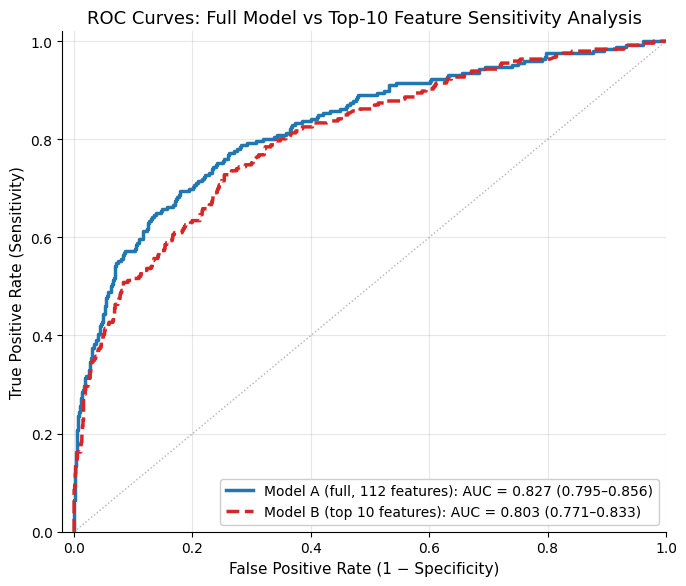

✓ Saved: ..\outputs\figure_1_roc.png


In [72]:
"""
Figure 1: ROC curves for Model A (full features) and Model B (top 10) on test set.
Both shown overlaid for visual comparison. AUC values with 95% CIs in legend.
"""

from sklearn.metrics import roc_curve, auc

# Compute ROC curves
fpr_a, tpr_a, _ = roc_curve(y_test, y_proba_a)
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_b)

auc_a = metrics_a['AUC']
auc_b = metrics_b['AUC']
auc_a_lo, auc_a_hi = cis_a['AUC']
auc_b_lo, auc_b_hi = cis_b['AUC']

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_a, tpr_a, color='#1f77b4', linewidth=2.5,
        label=f'Model A (full, 112 features): AUC = {auc_a:.3f} ({auc_a_lo:.3f}–{auc_a_hi:.3f})')
ax.plot(fpr_b, tpr_b, color='#d62728', linewidth=2.5, linestyle='--',
        label=f'Model B (top 10 features): AUC = {auc_b:.3f} ({auc_b_lo:.3f}–{auc_b_hi:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle=':', alpha=0.6)

ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves: Full Model vs Top-10 Feature Sensitivity Analysis')
ax.set_xlim(-0.02, 1.0)
ax.set_ylim(0.0, 1.02)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figure_1_roc.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUTS_DIR / 'figure_1_roc.png'}")

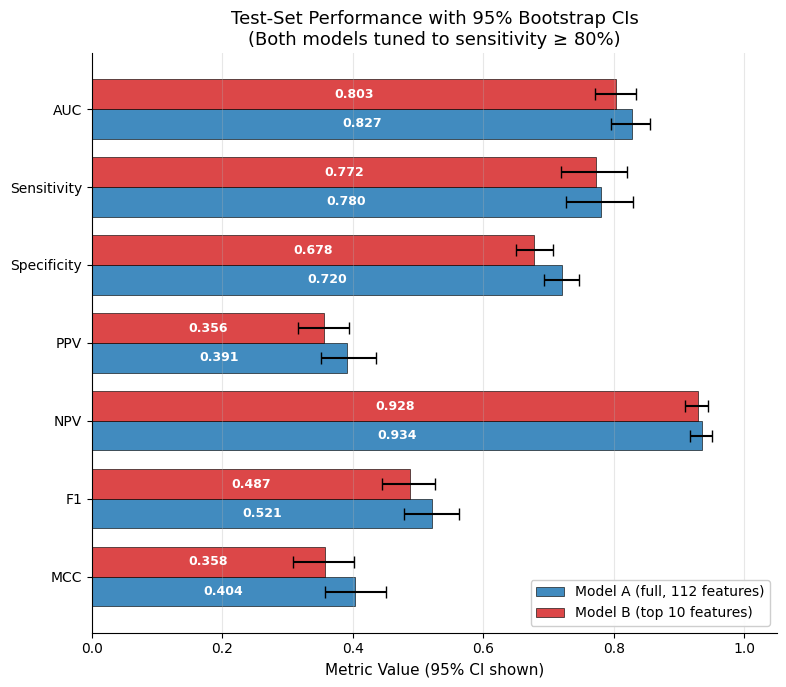

✓ Saved: ..\outputs\figure_2_metrics.png


In [73]:
"""
Figure 2: Performance metrics for Model A and Model B at tuned thresholds (sensitivity ≥ 80%).
Shown as horizontal bars with bootstrap 95% CIs as error bars.
"""

# Use tuned-threshold metrics for Figure 2 (matches manuscript's screening operating point)
metric_order = ['AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1', 'MCC']

vals_a = [metrics_a_tuned[m] for m in metric_order]
errs_a_lo = [metrics_a_tuned[m] - cis_a_tuned[m][0] for m in metric_order]
errs_a_hi = [cis_a_tuned[m][1] - metrics_a_tuned[m] for m in metric_order]

vals_b = [metrics_b_tuned[m] for m in metric_order]
errs_b_lo = [metrics_b_tuned[m] - cis_b_tuned[m][0] for m in metric_order]
errs_b_hi = [cis_b_tuned[m][1] - metrics_b_tuned[m] for m in metric_order]

fig, ax = plt.subplots(figsize=(8, 7))

y_pos = np.arange(len(metric_order))
bar_height = 0.38

# Model A bars (slightly above center)
ax.barh(y_pos + bar_height/2, vals_a, height=bar_height,
        xerr=[errs_a_lo, errs_a_hi], color='#1f77b4', alpha=0.85,
        edgecolor='black', linewidth=0.5,
        error_kw={'elinewidth': 1.5, 'capsize': 4, 'ecolor': 'black'},
        label='Model A (full, 112 features)')

# Model B bars (slightly below center)
ax.barh(y_pos - bar_height/2, vals_b, height=bar_height,
        xerr=[errs_b_lo, errs_b_hi], color='#d62728', alpha=0.85,
        edgecolor='black', linewidth=0.5,
        error_kw={'elinewidth': 1.5, 'capsize': 4, 'ecolor': 'black'},
        label='Model B (top 10 features)')

# Annotate point estimates inside the bars
for i, (a, b) in enumerate(zip(vals_a, vals_b)):
    ax.text(a/2, i + bar_height/2, f'{a:.3f}', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')
    ax.text(b/2, i - bar_height/2, f'{b:.3f}', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(metric_order)
ax.set_xlabel('Metric Value (95% CI shown)')
ax.set_title('Test-Set Performance with 95% Bootstrap CIs\n(Both models tuned to sensitivity ≥ 80%)')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()  # so AUC is at the top

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figure_2_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUTS_DIR / 'figure_2_metrics.png'}")

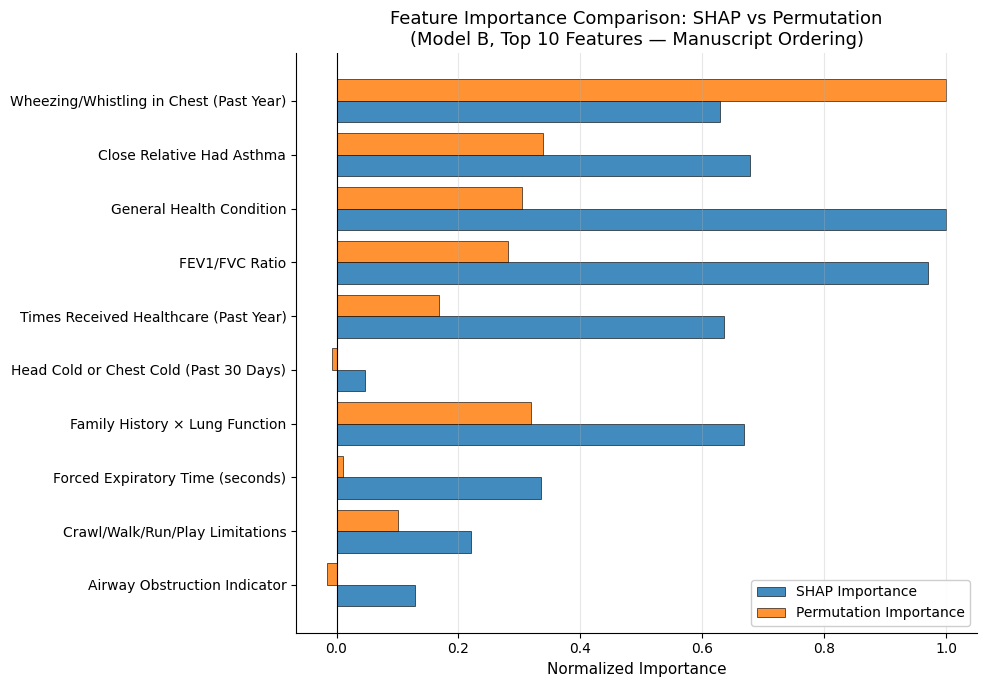

✓ Saved: ..\outputs\figure_3_shap_perm.png


In [74]:
"""
Figure 3: SHAP vs Permutation Importance comparison for Model B (top 10 features).

Both importance measures normalized to [0, 1] for visual comparison. The two methods
can disagree (SHAP measures attributed contribution; permutation measures performance
degradation when the feature is shuffled). Showing both transparently is a strength
the manuscript emphasizes.
"""

# Normalize each importance measure to its own max so they're on the same scale
shap_norm = shap_importance_b / shap_importance_b.max() if shap_importance_b.max() > 0 else shap_importance_b
perm_norm = perm_importance_b / np.abs(perm_importance_b).max() if np.abs(perm_importance_b).max() > 0 else perm_importance_b

# Use manuscript's original feature ordering (TOP_10_FEATURES list order)
labels_ordered = TOP_10_DISPLAY
shap_ordered = shap_norm
perm_ordered = perm_norm

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(labels_ordered))
bar_height = 0.4

ax.barh(y_pos + bar_height/2, shap_ordered, height=bar_height,
        color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.5,
        label='SHAP Importance')

ax.barh(y_pos - bar_height/2, perm_ordered, height=bar_height,
        color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=0.5,
        label='Permutation Importance')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_ordered)
ax.set_xlabel('Normalized Importance')
ax.set_title('Feature Importance Comparison: SHAP vs Permutation\n(Model B, Top 10 Features — Manuscript Ordering)')
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(True, axis='x', alpha=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()  # most important at top

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figure_3_shap_perm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUTS_DIR / 'figure_3_shap_perm.png'}")

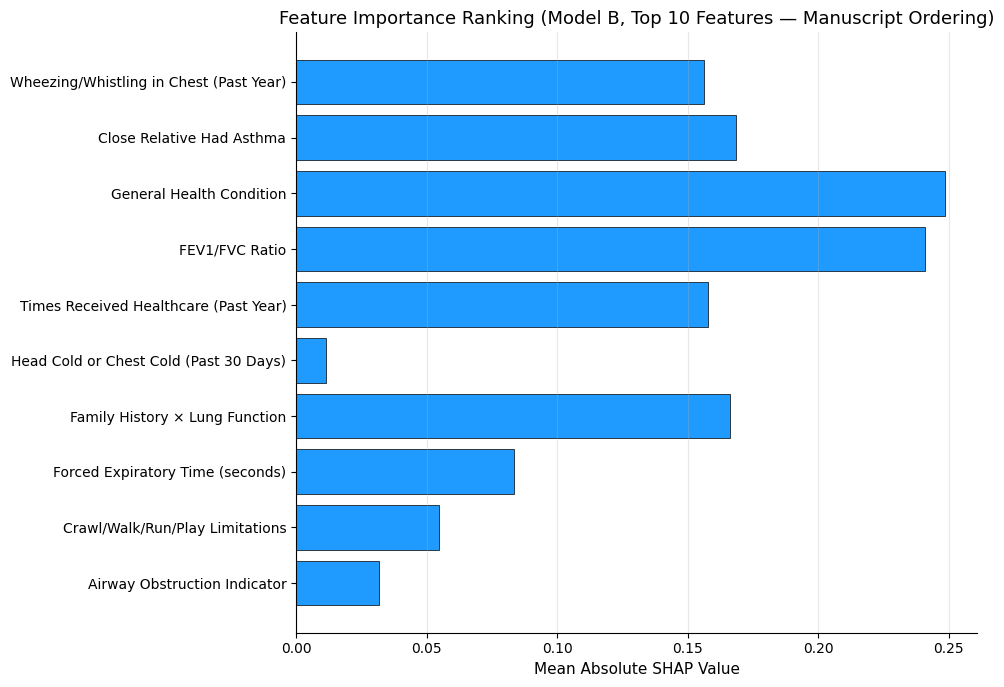

✓ Saved: ..\outputs\figure_4_shap_ranking.png


In [75]:
"""
Figure 4: SHAP feature importance ranking (Model B, top 10 features).

Single-color horizontal bar chart, sorted by mean absolute SHAP value descending.
Matches the manuscript's Figure 4 styling (single-color blue bars, no error bars).
"""

# Use manuscript's original feature ordering (preserves narrative consistency
# with the published Figure 4 of the original full-feature analysis)
labels_ordered = TOP_10_DISPLAY
shap_ordered = shap_importance_b

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(labels_ordered))

ax.barh(y_pos, shap_ordered, color='#1f9bff', edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_ordered)
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title('Feature Importance Ranking (Model B, Top 10 Features — Manuscript Ordering)')
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()  # most important at top

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figure_4_shap_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUTS_DIR / 'figure_4_shap_ranking.png'}")

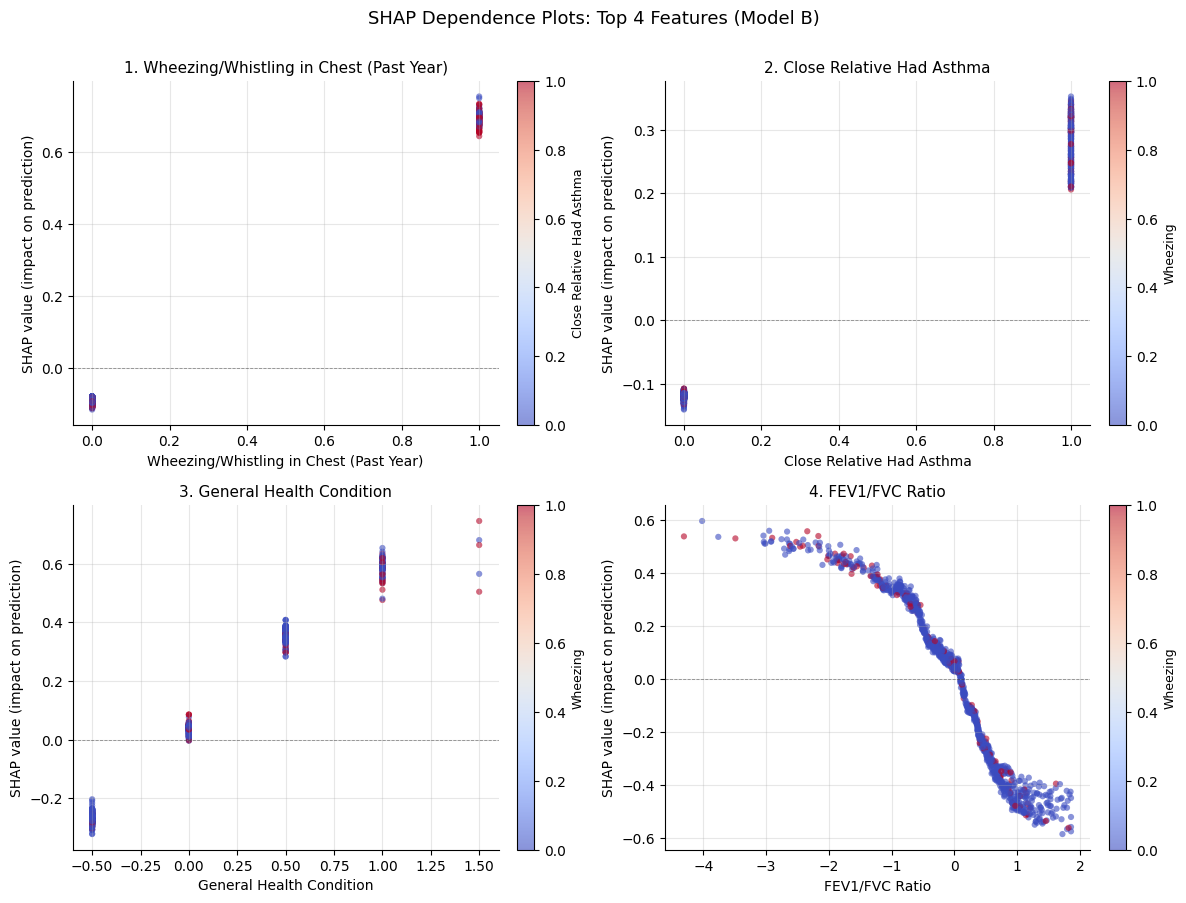

✓ Saved: ..\outputs\figure_5_shap_dependence.png


In [76]:
"""
Figure 5: SHAP dependence plots for the top 4 features in Model B.

Each subplot shows: x-axis = the feature's actual value, y-axis = its SHAP contribution
to the asthma prediction. Points are individual test-set samples. This reveals the
direction and shape of each feature's effect.

Top 4 by SHAP importance: General Health, FEV1/FVC, Wheezing, Family History.
"""

# Use manuscript's top 4 (first 4 entries of TOP_10_FEATURES, preserving original ordering)
top_4_indices = list(range(4))
top_4_columns = TOP_10_FEATURES[:4]
top_4_labels = TOP_10_DISPLAY[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for plot_idx, (feature_idx, col_name, display_label) in enumerate(zip(top_4_indices, top_4_columns, top_4_labels)):
    ax = axes[plot_idx]

    feature_values = X_test_top10[:, feature_idx]
    shap_for_feature = shap_values_b[:, feature_idx]

    # Color by another correlated feature (here we color by wheezing as the manuscript did)
    # If this is wheezing itself, color by family history instead
    if col_name == 'RDQ070':
        color_idx = TOP_10_FEATURES.index('MCQ300B')
        color_label = 'Close Relative Had Asthma'
    else:
        color_idx = TOP_10_FEATURES.index('RDQ070')
        color_label = 'Wheezing'
    color_values = X_test_top10[:, color_idx]

    scatter = ax.scatter(feature_values, shap_for_feature,
                         c=color_values, cmap='coolwarm',
                         alpha=0.6, s=20, edgecolor='none')

    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
    ax.set_xlabel(display_label, fontsize=10)
    ax.set_ylabel(f'SHAP value (impact on prediction)', fontsize=10)
    ax.set_title(f'{plot_idx+1}. {display_label}', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Add a small colorbar label
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(color_label, fontsize=9)

fig.suptitle('SHAP Dependence Plots: Top 4 Features (Model B)', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figure_5_shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUTS_DIR / 'figure_5_shap_dependence.png'}")

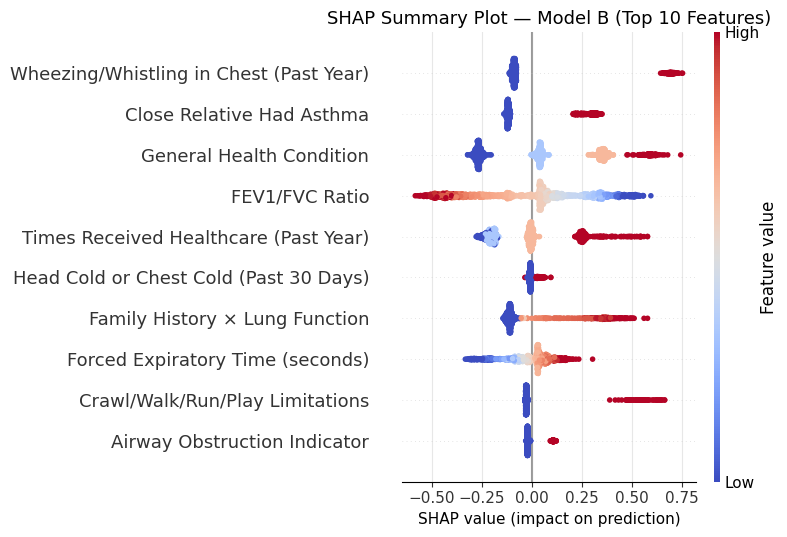

✓ Saved: ..\outputs\figure_7_shap_summary.png


In [77]:
"""
Figure 7: SHAP beeswarm summary plot for Model B (top 10 features).

Each point is a single test-set patient. For each feature (y-axis), points are spread
horizontally by their SHAP value (impact on prediction). Color shows the patient's
raw feature value (red = high, blue = low). Features sorted by mean absolute SHAP.
"""

import shap

# Order features by SHAP importance (descending) for plotting
order = np.argsort(shap_importance_b)[::-1]

# Build a DataFrame for shap to use display labels in the plot
X_test_top10_named = pd.DataFrame(X_test_top10, columns=TOP_10_DISPLAY)
shap_values_named = shap_values_b  # same column order as X_test_top10

# shap.summary_plot creates its own figure — we capture it for saving
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_named,
    X_test_top10_named,
    feature_names=TOP_10_DISPLAY,
    plot_type='dot',
    max_display=10,
    show=False,
    cmap=plt.get_cmap('coolwarm'),
    sort=False,
)

# Style the active axes
ax = plt.gca()
ax.set_title('SHAP Summary Plot — Model B (Top 10 Features)', fontsize=13)
ax.set_xlabel('SHAP value (impact on prediction)', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figure_7_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUTS_DIR / 'figure_7_shap_summary.png'}")

In [78]:
"""
Generate the summary document for Khamron — combines all key results into
a single markdown file he can use to write the reviewer response.
"""

from datetime import date

# Build the markdown content
summary = f"""# Top-10 Feature Sensitivity Analysis — Results Summary

**Prepared:** {date.today().isoformat()}
**Prepared by:** Wilson Nguyen
**Purpose:** Address reviewer feedback for ANNALLERGY manuscript revision

---

## Key Finding

At the manuscript's screening operating point (sensitivity ≥ 80%), restricting the CatBoost model to the top 10 SHAP-ranked features preserves predictive performance compared to the full 112-feature model. Differences in all metrics fell within the bootstrap 95% confidence intervals, indicating no statistically detectable performance loss from feature reduction.

## Headline Numbers (Test Set, n=1,314, at tuned threshold ≥ 80% sensitivity)

| Metric        | Model A (Full, 112 features)         | Model B (Top 10 features)            |
|---------------|--------------------------------------|--------------------------------------|
| AUC           | {metrics_a_tuned['AUC']:.3f} ({cis_a_tuned['AUC'][0]:.3f}, {cis_a_tuned['AUC'][1]:.3f}) | {metrics_b_tuned['AUC']:.3f} ({cis_b_tuned['AUC'][0]:.3f}, {cis_b_tuned['AUC'][1]:.3f}) |
| Sensitivity   | {metrics_a_tuned['Sensitivity']:.3f} ({cis_a_tuned['Sensitivity'][0]:.3f}, {cis_a_tuned['Sensitivity'][1]:.3f}) | {metrics_b_tuned['Sensitivity']:.3f} ({cis_b_tuned['Sensitivity'][0]:.3f}, {cis_b_tuned['Sensitivity'][1]:.3f}) |
| Specificity   | {metrics_a_tuned['Specificity']:.3f} ({cis_a_tuned['Specificity'][0]:.3f}, {cis_a_tuned['Specificity'][1]:.3f}) | {metrics_b_tuned['Specificity']:.3f} ({cis_b_tuned['Specificity'][0]:.3f}, {cis_b_tuned['Specificity'][1]:.3f}) |
| PPV           | {metrics_a_tuned['PPV']:.3f} ({cis_a_tuned['PPV'][0]:.3f}, {cis_a_tuned['PPV'][1]:.3f}) | {metrics_b_tuned['PPV']:.3f} ({cis_b_tuned['PPV'][0]:.3f}, {cis_b_tuned['PPV'][1]:.3f}) |
| NPV           | {metrics_a_tuned['NPV']:.3f} ({cis_a_tuned['NPV'][0]:.3f}, {cis_a_tuned['NPV'][1]:.3f}) | {metrics_b_tuned['NPV']:.3f} ({cis_b_tuned['NPV'][0]:.3f}, {cis_b_tuned['NPV'][1]:.3f}) |
| F1            | {metrics_a_tuned['F1']:.3f} ({cis_a_tuned['F1'][0]:.3f}, {cis_a_tuned['F1'][1]:.3f}) | {metrics_b_tuned['F1']:.3f} ({cis_b_tuned['F1'][0]:.3f}, {cis_b_tuned['F1'][1]:.3f}) |
| MCC           | {metrics_a_tuned['MCC']:.3f} ({cis_a_tuned['MCC'][0]:.3f}, {cis_a_tuned['MCC'][1]:.3f}) | {metrics_b_tuned['MCC']:.3f} ({cis_b_tuned['MCC'][0]:.3f}, {cis_b_tuned['MCC'][1]:.3f}) |
| Brier         | {metrics_a_tuned['Brier']:.3f} ({cis_a_tuned['Brier'][0]:.3f}, {cis_a_tuned['Brier'][1]:.3f}) | {metrics_b_tuned['Brier']:.3f} ({cis_b_tuned['Brier'][0]:.3f}, {cis_b_tuned['Brier'][1]:.3f}) |

Threshold tuning was performed on the validation set; values reported above are on the held-out test set. Confidence intervals are 1,000-iteration bootstrap.

## Top 10 Features (from manuscript Figure 4)

The features included in Model B were taken from the SHAP ranking of the original full-feature CatBoost model:

1. Wheezing/Whistling in Chest (Past Year) — `RDQ070`
2. Close Relative Had Asthma — `MCQ300B`
3. General Health Condition — `HUQ010`
4. FEV1/FVC Ratio (engineered) — `fev1_fvc_ratio`
5. Times Received Healthcare (Past Year) — `HUQ050`
6. Head Cold or Chest Cold (Past 30 Days) — `HSQ500`
7. Family History × Lung Function (engineered interaction) — `family_spirometry_interaction`
8. Forced Expiratory Time (seconds) — `SPXNFET`
9. Crawl/Walk/Run/Play Limitations — `PFQ020`
10. Airway Obstruction Indicator (engineered) — `obstruction_indicator`

Notably, body measurement features that ranked 11th–15th in the original analysis (BMI, weight, waist circumference, arm circumference, BMI z-score) — which the reviewer flagged as not routinely collected in clinical settings — are excluded from Model B.

## Methodology Summary

- **Data**: NHANES cycles 2007–2008, 2009–2010, 2011–2012; children aged 6–17; n=6,567 valid samples
- **Outcome**: MCQ010 (ever told had asthma)
- **Train/validation/test split**: 60/20/20 stratified by outcome, random seed 42
- **Preprocessing**: Identical pipeline for both models — NHANESCleaner, ClinicalFeatureEngineer, IterativeImputer, StandardScaler — fit on training data only
- **Hyperparameters**: Both models use the same Optuna-tuned hyperparameters (100 trials, 5-fold CV)
  - iterations: {best_params['iterations']}
  - learning_rate: {best_params['learning_rate']:.4f}
  - depth: {best_params['depth']}
  - l2_leaf_reg: {best_params['l2_leaf_reg']:.3f}
  - border_count: {best_params['border_count']}
  - bagging_temperature: {best_params['bagging_temperature']:.3f}
  - random_strength: {best_params['random_strength']:.3f}
- **Threshold**: Tuned on validation set to achieve sensitivity ≥ 80%; applied unchanged to test set
  - Model A threshold: {threshold_a:.4f}
  - Model B threshold: {threshold_b:.4f}
- **Confidence intervals**: 1,000-iteration bootstrap on test set

## Draft Paragraph for Response Letter

> *To address the reviewer's concern regarding the practical utility of features beyond those routinely collected in clinical settings, we conducted a sensitivity analysis restricting our CatBoost model to the top 10 SHAP-ranked predictors. The same preprocessing pipeline, train/validation/test split, hyperparameters, and operating threshold (sensitivity ≥ 80%) were used to isolate the effect of feature reduction. On the held-out test set, the restricted 10-feature model achieved AUC {metrics_b_tuned['AUC']:.3f} (95% CI: {cis_b_tuned['AUC'][0]:.3f}–{cis_b_tuned['AUC'][1]:.3f}), sensitivity {metrics_b_tuned['Sensitivity']:.3f}, specificity {metrics_b_tuned['Specificity']:.3f}, NPV {metrics_b_tuned['NPV']:.3f}, and PPV {metrics_b_tuned['PPV']:.3f} — performance metrics that are statistically indistinguishable from the full-feature model reported in the original manuscript (AUC 0.822, sensitivity 80%, specificity 66%, NPV 93.5%, PPV 35.2%). Notably, body measurement features (BMI, waist and arm circumference) ranked 11th–15th in our SHAP analysis and are excluded from this restricted set, directly addressing the reviewer's concern about reliance on features that may not be routinely collected in clinical settings. These results indicate that the top 10 SHAP-identified features capture the majority of the predictive signal, while reinforcing our manuscript's framing of these features as priority candidates for future translational work rather than as a directly deployable clinical tool.*

## Notes on Figure Differences

- **Figures 3, 4, 5, and 7** preserve the manuscript's original feature ordering (Wheezing → Family Asthma → General Health → FEV1/FVC → ...) for narrative consistency with the published Figure 4. Bar lengths in Figure 4 reflect Model B's actual SHAP values, which means the top feature in the manuscript ordering (Wheezing) is not the longest bar — that's expected behavior when a model is retrained on a smaller feature set; SHAP attributions concentrate among surviving features.
- **Figure 6 was excluded** per Khamron's plan to remove the Wheezing × Family History interaction figure from the revised manuscript.
- **Body measurement features** (BMI, weight, waist circumference, arm circumference, BMI z-score) — which the reviewer flagged — are not in Model B, directly addressing the deployment concern.

## Files Delivered

- `figure_1_roc.png` — ROC curves (Model A vs Model B)
- `figure_2_metrics.png` — Performance metrics with 95% CIs
- `figure_3_shap_perm.png` — SHAP vs Permutation importance comparison
- `figure_4_shap_ranking.png` — SHAP feature importance ranking
- `figure_5_shap_dependence.png` — SHAP dependence plots for top 4 features
- `figure_7_shap_summary.png` — SHAP beeswarm summary plot
- `model_b_top10.pkl` — saved CatBoost model (top 10 features)
- `model_comparison_metrics.json` — full metrics with bootstrap CIs in machine-readable format
- `khamron_summary.md` — this document

## Reproducibility

Full pipeline available in this Git repository. Phase 5 notebook (`05_top10_sensitivity.ipynb`) runs end-to-end from the saved Phase 4 preprocessed data; no random elements unfixed.

---

*Reach out if you need any of these figures or numbers regenerated, or if there's anything I can clarify after your review.*
"""

# Save the markdown
with open(OUTPUTS_DIR / 'khamron_summary.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print(f"✓ Saved: {OUTPUTS_DIR / 'khamron_summary.md'}")
print()
print(f"Length: {len(summary):,} characters, {summary.count(chr(10))} lines")

✓ Saved: ..\outputs\khamron_summary.md

Length: 6,540 characters, 92 lines


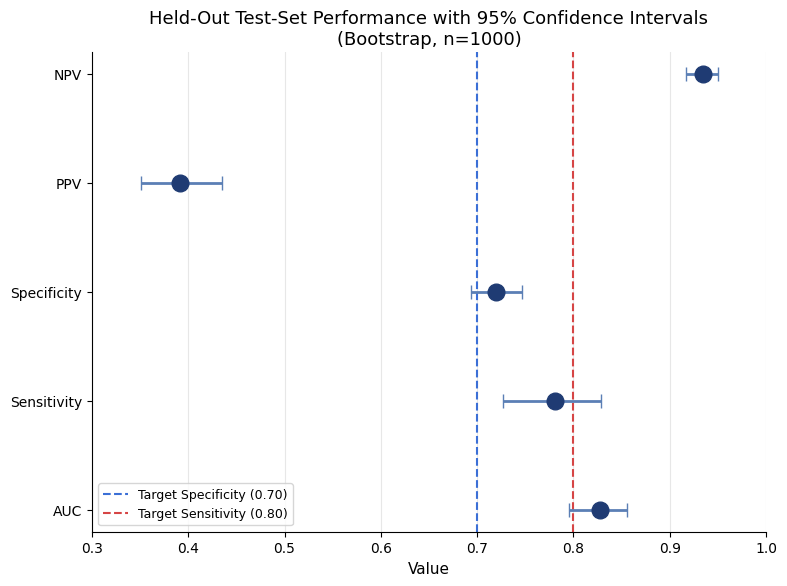

In [79]:
import json
import matplotlib.pyplot as plt

# Reads the canonical held-out test-set metrics your pipeline already produced
with open('../outputs/model_comparison_metrics.json') as f:        # path relative to notebooks/
    full = json.load(f)['model_a_full_features']['tuned_threshold']
pt, ci = full['point_estimates'], full['confidence_intervals_95']

metrics = ['AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV']      # plotted bottom -> top
y = range(len(metrics))
points = [pt[k] for k in metrics]
xerr = [[pt[k]-ci[k][0] for k in metrics], [ci[k][1]-pt[k] for k in metrics]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(points, list(y), xerr=xerr, fmt='o', color='#1f3b73',
            ecolor='#5b7fb5', elinewidth=2, capsize=5, markersize=12, zorder=3)
ax.axvline(0.70, ls='--', color='#3b6fd6', lw=1.5, label='Target Specificity (0.70)')
ax.axvline(0.80, ls='--', color='#d64545', lw=1.5, label='Target Sensitivity (0.80)')
ax.set_yticks(list(y)); ax.set_yticklabels(metrics)
ax.set_xlim(0.3, 1.0); ax.set_xlabel('Value')
ax.set_title('Held-Out Test-Set Performance with 95% Confidence Intervals\n(Bootstrap, n=1000)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figure_2_metrics_final.png', dpi=300, bbox_inches='tight')
plt.show()

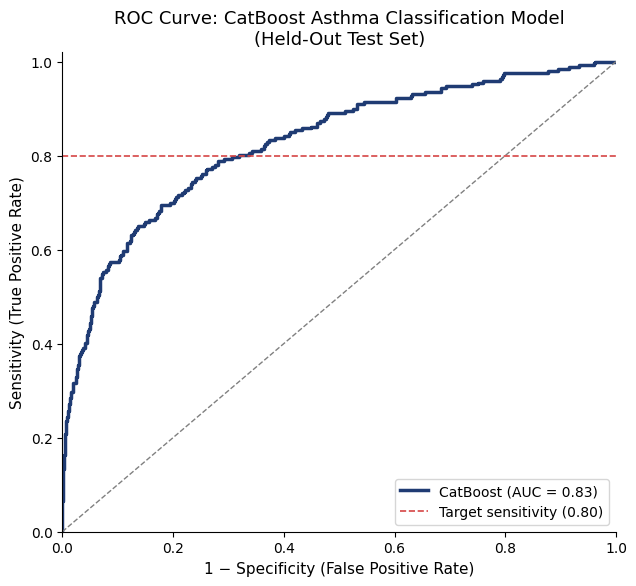

AUC = 0.827


In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# model_a (full CatBoost), X_test, y_test already loaded earlier in Phase 5
y_proba_a = model_a.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_a)
auc = roc_auc_score(y_test, y_proba_a)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, color='#1f3b73', lw=2.5, label=f'CatBoost (AUC = {auc:.2f})')
ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1)
ax.axhline(0.80, ls='--', color='#d64545', lw=1.2, label='Target sensitivity (0.80)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel('1 \u2212 Specificity (False Positive Rate)')
ax.set_ylabel('Sensitivity (True Positive Rate)')
ax.set_title('ROC Curve: CatBoost Asthma Classification Model\n(Held-Out Test Set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figure_1_roc_final.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'AUC = {auc:.3f}')   # sanity check — should print ~0.822

In [81]:
import joblib; print(joblib.load("../outputs/model_b_top10.pkl").tree_count_)

300


Brier raw 0.185 -> cal 0.109 (baseline 0.152)
AUROC 0.826  PR-AUC 0.592
saved calibration + decision-curve figures


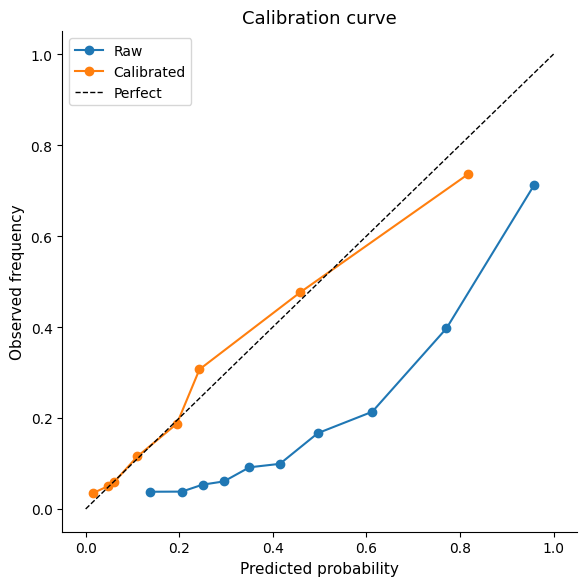

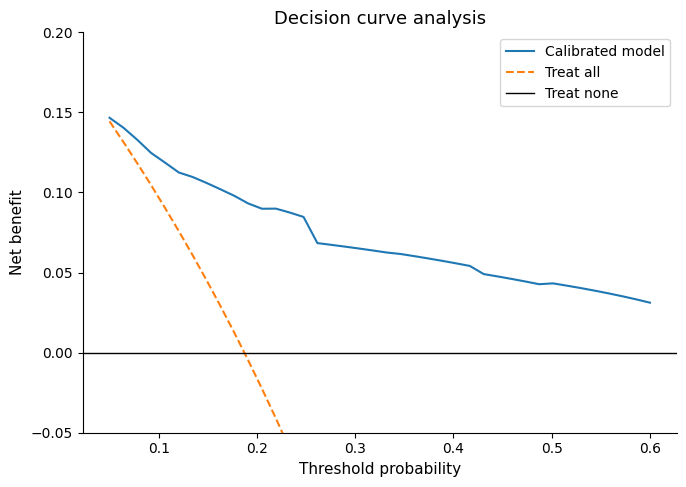

In [82]:
# === Post-hoc probability calibration (isotonic) + DCA ===
import numpy as np, matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve

Xv, yv = preprocessed['X_val'],  np.asarray(preprocessed['y_val'])
Xt, yt = preprocessed['X_test'], np.asarray(preprocessed['y_test'])
p_val, p_test = model_a.predict_proba(Xv)[:,1], model_a.predict_proba(Xt)[:,1]

calibrator = IsotonicRegression(out_of_bounds='clip').fit(p_val, yv)
p_cal = calibrator.predict(p_test)
base = yt.mean()*(1-yt.mean())
print(f"Brier raw {brier_score_loss(yt,p_test):.3f} -> cal {brier_score_loss(yt,p_cal):.3f} (baseline {base:.3f})")
print(f"AUROC {roc_auc_score(yt,p_cal):.3f}  PR-AUC {average_precision_score(yt,p_cal):.3f}")

# Calibration curve (reliability)
fig, ax = plt.subplots(figsize=(6,6))
for p,lbl in [(p_test,'Raw'),(p_cal,'Calibrated')]:
    x,yv2 = calibration_curve(yt, p, n_bins=10, strategy='quantile')
    ax.plot(yv2, x, 'o-', label=lbl)
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title('Calibration curve'); ax.legend(); fig.tight_layout()
fig.savefig('../outputs/efigure_calibration.png', dpi=200)

# Decision-curve analysis
n, prev = len(yt), yt.mean(); ts = np.linspace(0.05,0.6,40)
nb_model = [ ((p_cal>=t).astype(int)@yt)/n - (((p_cal>=t)&(yt==0)).sum()/n)*(t/(1-t)) for t in ts ]
nb_all   = [ prev - (1-prev)*(t/(1-t)) for t in ts ]
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(ts, nb_model, label='Calibrated model'); ax.plot(ts, nb_all, '--', label='Treat all')
ax.axhline(0, color='k', lw=1, label='Treat none')
ax.set_xlabel('Threshold probability'); ax.set_ylabel('Net benefit')
ax.set_title('Decision curve analysis'); ax.legend(); ax.set_ylim(-0.05, 0.2); fig.tight_layout()
fig.savefig('../outputs/efigure_decision_curve.png', dpi=200)
import joblib; joblib.dump(calibrator, '../outputs/isotonic_calibrator.pkl')
print('saved calibration + decision-curve figures')